© Copyright, 2026 G. Schaer.

SPDX-License-Identifier: GPL-3.0-only

# The Single Axis Control Moment Gyroscope Problem

## Introduction

In this project, we are designing a controller that will balance a pendulum upright. This is exactly like trying to balance an upright pencil on your palm by moving your hand around. In this problem, a mass is attached to the end of a rigid, massless rod. This massless rod is then fixed to a ring that is free to roll side to side. Inside the ring is a ***single-axis control moment gyroscope (CMG)*** comprised of a yawing ***gimbal*** and a rotating ***flywheel***. The goal of the project is to determine how to twist (yaw) the gimbal so that the pendulum remains upright. To solve this problem, we are taking an approach called "model-based control". This means that our controller design will be based on a model of the dynamics of the system. The first step, then, is to use the Lagrangian mechanics formulation to derive the equations of motion.

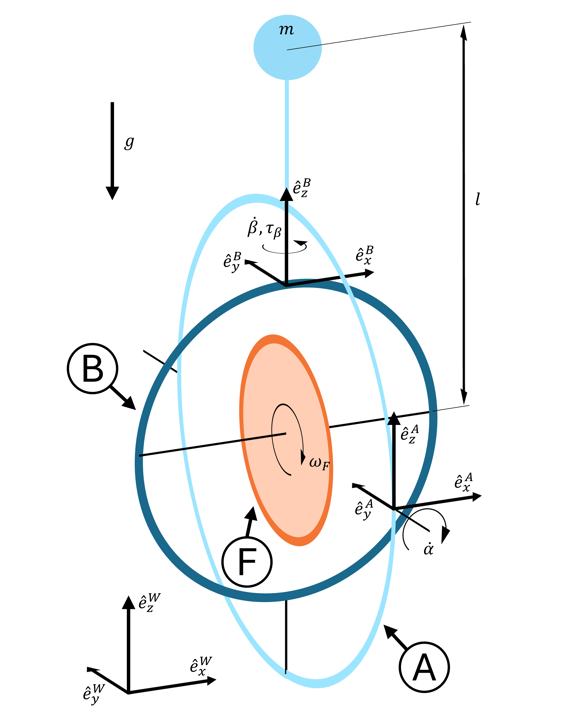

Control-moment gyroscopes are a type of non-propulsive actuator, i.e., it does not consume fuel, that are commonly used to control the attitude of spacecraft that generate reaction torque via gyroscopic forces induced by rotating an angular momentum vector. In particular, if the flywheel is spun at a high rate, then an “input torque” applied to the CMG's gimbal will, through conservation of angular momentum, result in an “output torque” being applied to the chassis holding the CMG (in this case the pendulum ring) about an axis perpendicular both to the gimbal axis and the rotor axis.

One advantage of using CMGs over other forms of non-propulsive actuators, such as reaction wheels, is that thier output torque can be much higher than their input torques — a so-called “torque amplification” effect. That is to say, CMGs have the ability to generate large torques with relatively low power consumption. This makes them well-suited for long-duration space missions — including geosynchronous satellites and interplanetary probes — where power and weight constraints are significant considerations. This also means that CMGs can, in general, produce much larger torques than reaction wheels, which can be useful for attitude control of very large spacecraft. The International Space Station (ISS) is one example of a large spacecraft whose attitude is controlled by CMGs — here is an image of a CMG being installed on ISS by an STS-118 crew member:

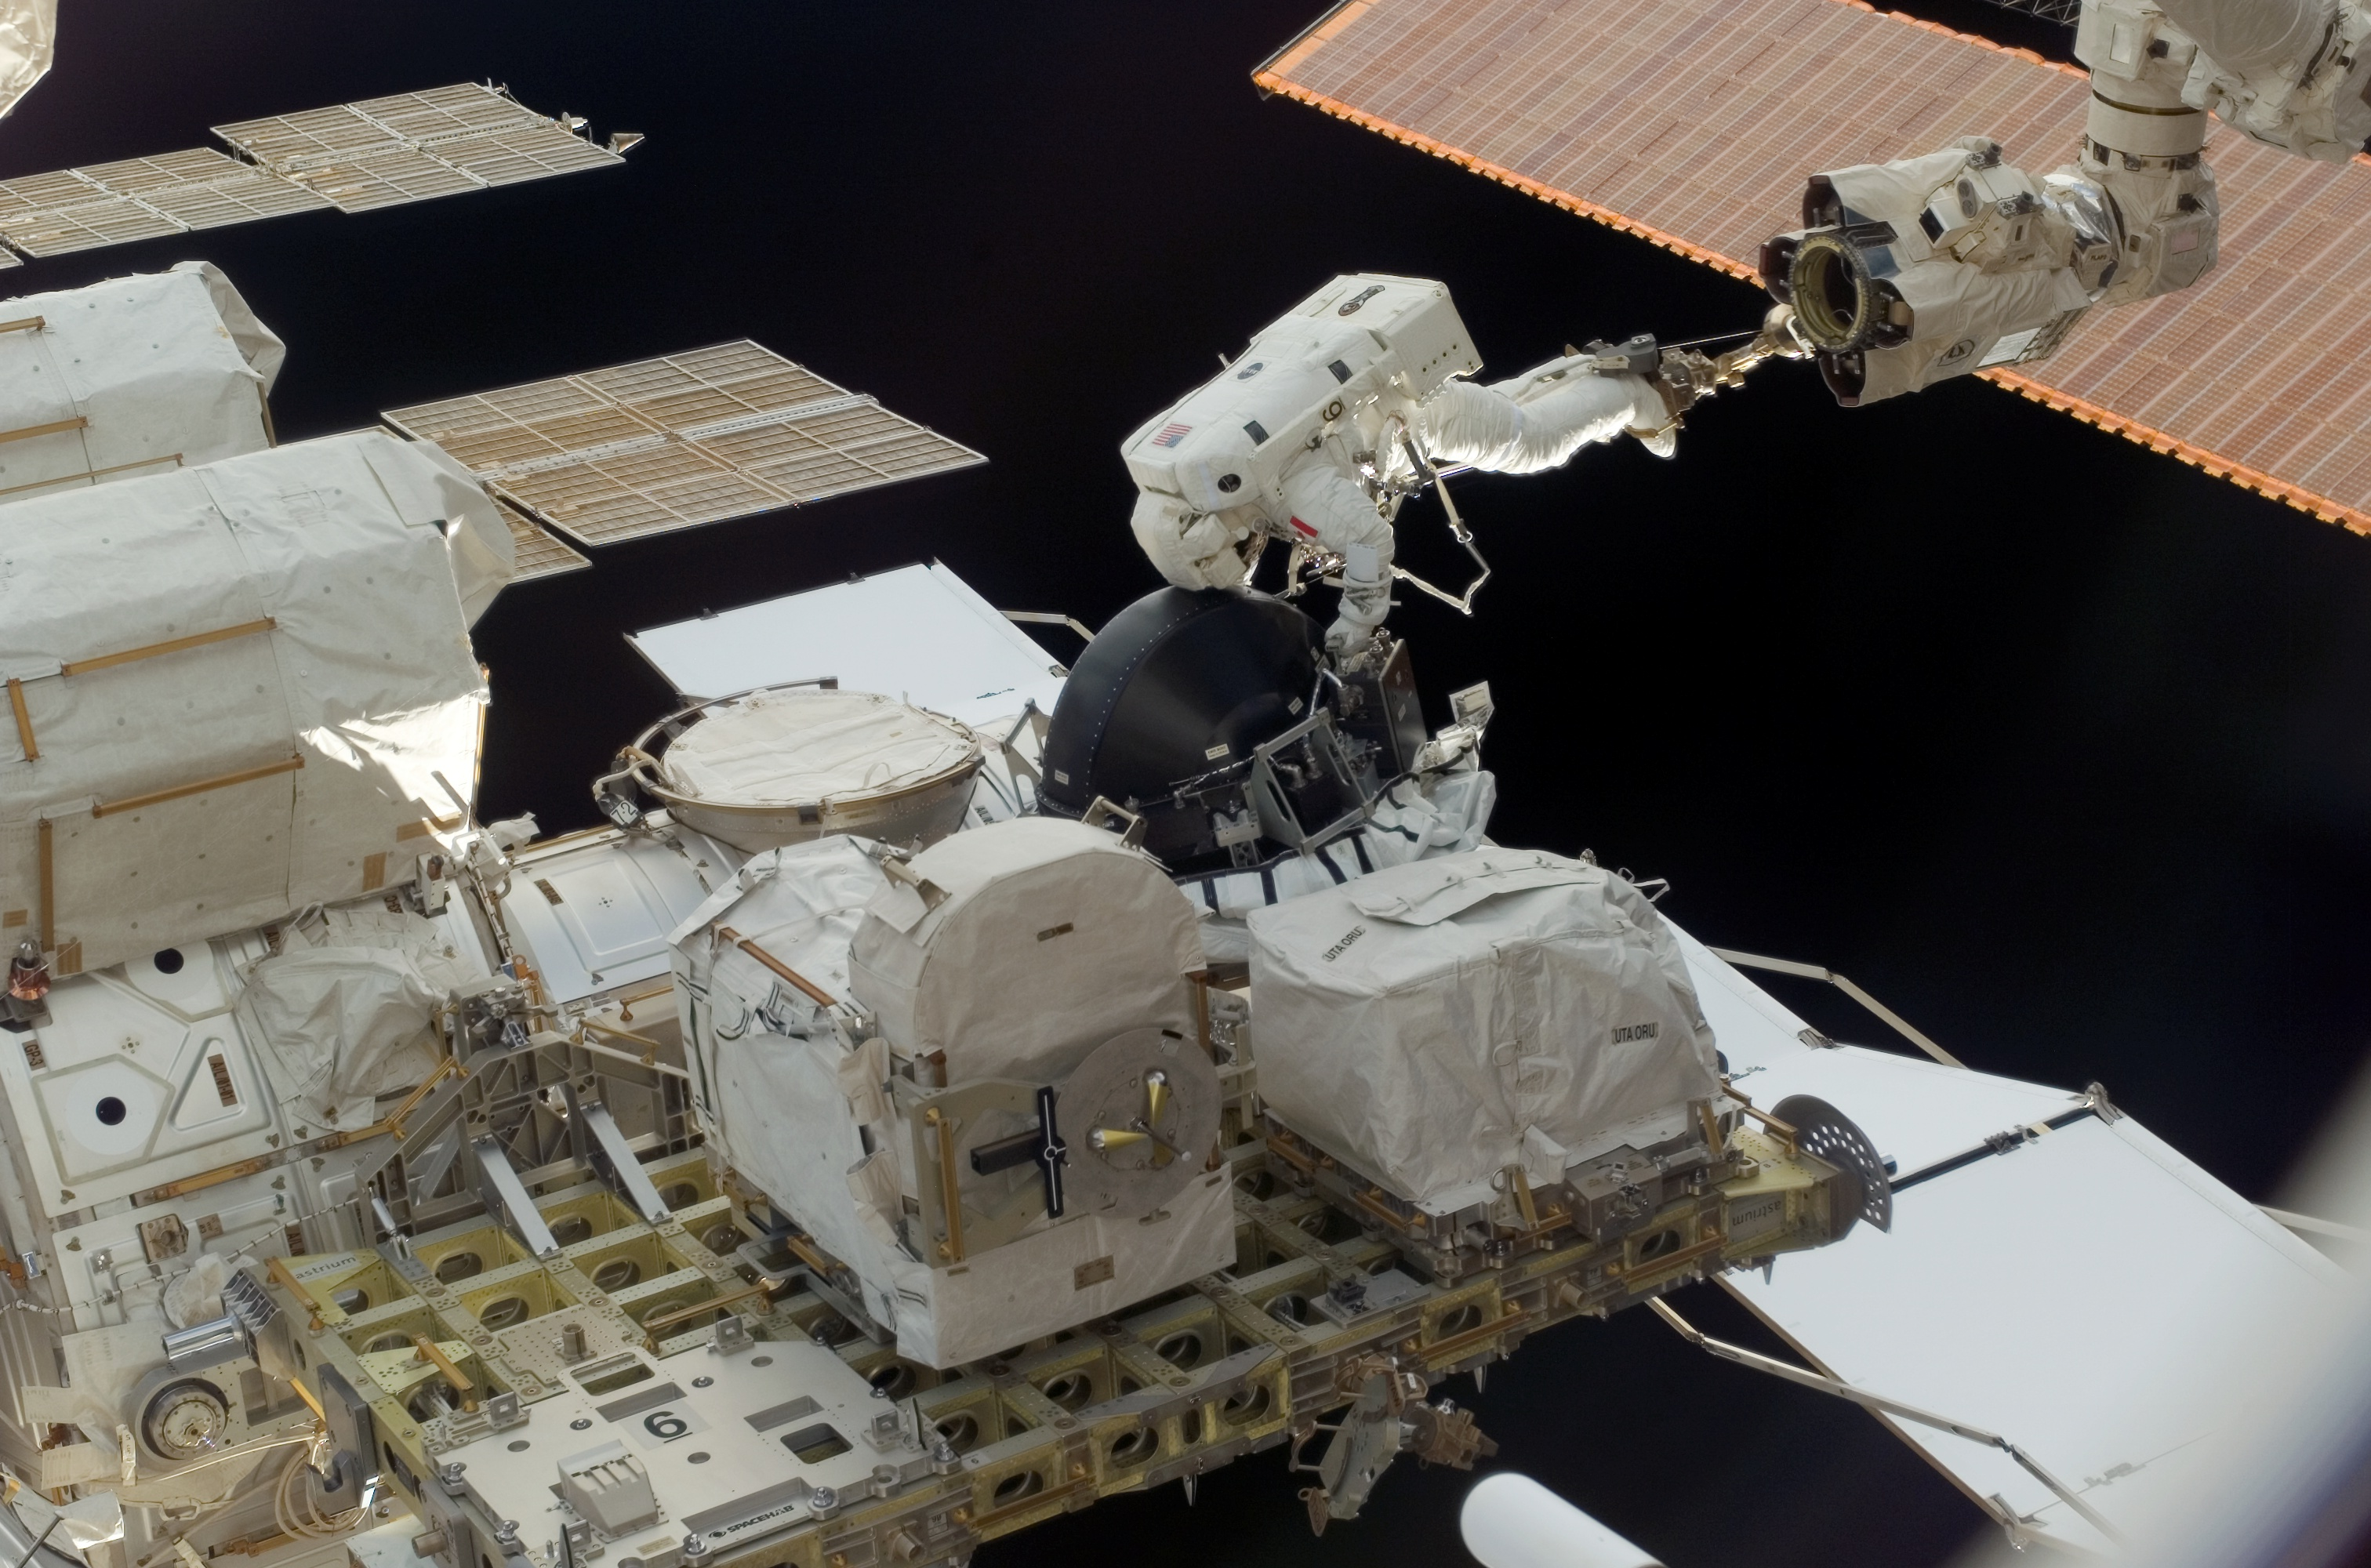

The ISS uses four double-axis CMGs rather than the one single-axis CMG you will be considering in this project, although the principles of operation are similar (we will investigate double-axis CMGs in the next project in this series). Its CMGs have a life expectency of about 10 years, contain a flywheel that spins at 691 rad/s (6600 rpm), and can produce an output torque of 258 N-m (190 ft-lbf). The orientation of ISS can be fine-tuned to point exactly at a target by controlling the tilt of each CMG.

There are disadvantages to using CMGs instead of reaction wheels, of course. One disadvantage, for example, is that the dynamics of a CMG are more complicated than those of a reaction wheel and require a more sophisticated controller.

This first design project will familiarize you with the operational concepts and physics behind the use of CMGs on modern spacecraft, and in particular will give you a sense of what it takes to control them.

You can read more about CMGs and their use for spacecraft attitude control in [Fundamentals of Spacecraft Attitude Determination and Control (Markley and Crassidis, 2014)](https://link.springer.com/book/10.1007/978-1-4939-0802-8).

## The Process

To design a model-based controller, we will take 6 steps:
1. Determine the equations of motion of the system
2. Place the equations of motion in standard form
3. Linearize the standard form equations
4. Select a gain matrix that stablizes the system
5. Build a controller with our gain matrix
6. Simulate the system

## 1. System Dynamics and Equations of Motion

Let's derive a dynamic model of the CMG. From the diagram above, we see there are four major components, the pendulum ring, called $A$, the mass at the top of the pendulum ring, the gimbal inside the pendulum ring, called $B$, and the flywheel inside the gimbal, called $F$. There are two ***generalized coordinates*** for our system: the roll of the pendulum ring, $\alpha$ and the yaw of the gimbal, $\beta$. Additionally, a yawing torque, $\tau_\beta$ is applied to the gimbal.

The first step in the Lagrangian mechanics approach to deriving the equations of motion of a system is to calculate the kinetic and potential energies of the system with respect to the generalized coordinates and their derivatives. We can do this using the Python package Sympy.

In [1]:
# Import everything we need from SymPy
import sympy as sym
import numpy as np
from sympy import Symbol, Matrix, Function, Derivative, N
from sympy import diff, simplify, nsimplify, sin, cos, solve, init_printing, symbols, lambdify
init_printing() # This function will make the outputs of SymPy look prettier and be easier to read

Now we are going to define the ***parameters*** of the system, that is, the system constants. Acceleration due to gravity is called $g$. The pendulum mass is called $m$. All components save the pendulum mass have thier own moments of inertial: $I_A^A$ for the pendulum ring, $I_B^B$ for the gimbal, and $I_F^B$ for the flywheel. Here, $I_j^k$ denotes the moment of inertia tensor of object $j$ in the inertial frame of object $k$. Additionally, the flywheel is spinning at a constant rotation rate, $\omega_F$. Finally, the pendulum has an effective arm length, that is the total distance the pendulum mass is suspended away from the rotation axis, of $l$. 

In [2]:
# Define all the system parameters
omega_F = 314
m = 0.0221
g = 9.81
l = 0.15
I_AA = np.array([[0.000937, 0, 0],
                 [0, 0.000476, 0],
                 [0, 0, 0.000476]]) # The moment of inertia of the pendulum in kg-m^2 in its own frame
I_BB = np.array([[0.0000777, 0, 0],
                 [0, 0.000148, 0],
                 [0, 0, 0.0000777]]) # The moment of inertia of the gimbal in kg-m^2 in its own frame
I_FB = np.array([[0.000235, 0, 0],
                 [0, 0.000164, 0],
                 [0, 0, 0.000164]]) # The moment of inertia of the flywheel in kg-m^2 in the gimbal's inertial frame

Now we make symbols and functions. These are elements of SymPy and can be thought of as exactly the same as symbols (variables) and functions from math.

In [3]:
# Time is a symbol (variable)
t = Symbol('t')

# The generalized coordinates and the inputs are both functions of time.
# This means that they are initialized as Functions.
alpha = Function('alpha')
beta = Function('beta')
tau_beta = Function('tau_beta')

Next up, we can start the process of defining the dynamics of the system. We begin by defining the set of rotation matrices that transform one inertial from to another inertial frame. After calculated, in the pursuit of calculating rotational energy, we use these transformation matrices to convert angular rates to angular velocities.

In [4]:
# Calculate the rotation matrices between the adjacent inertial frames
R_AW = Matrix([[ cos(alpha(t)), 0, sin(alpha(t))],
               [ 0,             1, 0          ],
               [-sin(alpha(t)), 0, cos(alpha(t))]])
R_BA = Matrix([[cos(beta(t)), -sin(beta(t)), 0],
               [sin(beta(t)),  cos(beta(t)), 0],
               [0,             0,            1]])

In [5]:
# Get the angular velocities of each component in their own inertial frames
ang_vel_A_A = Matrix([0, diff(alpha(t), t), 0])
ang_vel_B_B = Matrix([0, 0, diff(beta(t), t)]) + R_BA.T @ ang_vel_A_A
ang_vel_F_B = Matrix([omega_F, 0, 0]) + ang_vel_B_B

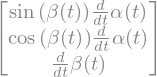

In [6]:
ang_vel_B_B

In [7]:
# Get the rotational energies of each component
T_A = simplify(sym.trigsimp((0.5 * ang_vel_A_A.T @ I_AA @ ang_vel_A_A)[0, 0]))
T_B = simplify(sym.trigsimp((0.5 * ang_vel_B_B.T @ I_BB @ ang_vel_B_B)[0, 0]))
T_F = simplify(sym.trigsimp((0.5 * ang_vel_F_B.T @ I_FB @ ang_vel_F_B)[0, 0]))

Now that we have the rotational energies of the pendulum, gimbal, and flywheel, the only other energies left to calculate are the kinetic and potential energy of the pendulum mass.

In [8]:
# Get the energies of the mass based on its position
mass_pos = R_AW.T @ Matrix([0, 0, l])
mass_vel = diff(mass_pos, t)
T_mass = simplify(sym.trigsimp((0.5 * m * mass_vel.T @ mass_vel)[0, 0]))
V_mass = m*g*l*cos(alpha(t))

Now we calculate the ***lagrangian*** of the system, $L$, via the formula:$$L=T-V$$ where $T$ is the total kinetic energy and $V$ is the total potential energy.

System Lagrangian:


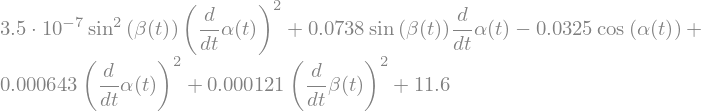

In [9]:
# Get the system Lagrangian
T = T_mass + T_A + T_B + T_F
V = V_mass
L = simplify(sym.trigsimp((T - V)))
print('System Lagrangian:')
N(L,3)

Given the Lagrangian, the equations of motion of the system are defined via the nonconservative ***Euler-Lagrange equations***:
$$\frac{d}{dt} \left( \frac{\partial L}{\partial \dot{q_j}} \right) - \frac{\partial L}{\partial q_j} = F_j$$

Where $q_j$ is the $j$th generalized coordinate of the system and $F_j$ is the applied (external) input acting on the $j$th generalized coordinate. For this system, then, the Euler-Lagrange equations take the form:

$$\frac{d}{dt} \left( \frac{\partial L}{\partial \dot{\alpha}} \right) - \frac{\partial L}{\partial \alpha}=0$$
$$\frac{d}{dt} \left( \frac{\partial L}{\partial \dot{\beta}} \right) - \frac{\partial L}{\partial \beta}=\tau_\beta$$

Solving these equations:

In [10]:
# Get the left hand side of the equations of motion
f1 = diff(diff(L, Derivative(alpha(t), t)), t) - diff(L, alpha(t))
f2 = diff(diff(L, Derivative(beta(t), t)), t) - diff(L, beta(t)) - tau_beta(t)

Currently, the equations of motion are in the form:
$$
f_1 \left( \frac{\partial^{2} \alpha}{\partial t^{2}}, \frac{\partial^{2} \beta}{\partial t^{2}}, \frac{\partial \alpha}{\partial t}, \frac{\partial \beta}{\partial t}, \alpha, \beta, \tau_\beta \right) = 0
$$
$$
f_2 \left( \frac{\partial^{2} \alpha}{\partial t^{2}}, \frac{\partial^{2} \beta}{\partial t^{2}}, \frac{\partial \alpha}{\partial t}, \frac{\partial \beta}{\partial t}, \alpha, \beta, \tau_\beta \right) = 0
$$

This form of equations of motion is not very helpful to us right now, so next we will place them in the form:
$$
\frac{\partial^{2} \alpha}{\partial t^{2}} = f_{\alpha} \left( \frac{\partial \alpha}{\partial t}, \frac{\partial \beta}{\partial t}, \alpha, \beta, \tau_\beta \right)
$$
$$
\frac{\partial^{2} \beta}{\partial t^{2}} = f_{\beta} \left( \frac{\partial \alpha}{\partial t}, \frac{\partial \beta}{\partial t}, \alpha, \beta, \tau_\beta \right)
$$

In [11]:
# Solve the equations of motion for the second order terms
soln = solve([f1, f2], Derivative(alpha(t), (t, 2)), Derivative(beta(t), (t, 2)))
f_alpha = sym.trigsimp((soln[Derivative(alpha(t), (t, 2))]))
f_beta = sym.trigsimp((soln[Derivative(beta(t), (t, 2))]))

Let's now combine these two equations into a single vector and replace the functions of time with symbols (this will make the linearization steps easier).

In [12]:
# Build the equations of motion vector
f = Matrix([f_alpha, f_beta])

# Replace the functions of time with symbols
(alphadot_sym, betadot_sym, alpha_sym, beta_sym, tau_beta_sym) = symbols('alphadot, betadot, alpha, beta, tau_beta')
f = f.subs({Derivative(alpha(t), t) : alphadot_sym,
            Derivative(beta(t), t) : betadot_sym,
            alpha(t) : alpha_sym,
            beta(t) : beta_sym,
            tau_beta(t) : tau_beta_sym,})

Now we have $f$ as our system model such that:
$$
\begin{bmatrix}
\ddot{\alpha} \\
\ddot{\beta} \\
\end{bmatrix} = f(\dot{\alpha}, \dot{\beta}, \alpha, \beta, \tau_\beta)
$$

Equations of Motion:


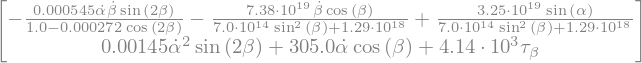

In [13]:
print('Equations of Motion:')
N(f,3)

## 2. Standard Form

For model-based controls, a ***standard form*** of equations of motion is typically used:
$$
\dot{\mathbf{m}} = f(\mathbf{m}, \mathbf{n}),
$$

where $\mathbf{m}$ is the ***nonlinear state vector*** and $\mathbf{n}$ is the ***nonlinear input vector***.

There are two major differences between our current system and a system in standard form:
1. All the equations in our system are *second order*. Standard form requires all equations to be *first order*.
2. There are dervative arguments in our current system, $f$. Standard form requires that all arguments to $f$ are *zeroth order*. 

To fix problem 1, we need to replace both our *second order* differential equations with two *first order* differential equations. To do this, we can define two new variables: $\omega_{\alpha}$ and $\omega_{\beta}$. We define these new variables via the differential equations:
$$
\dot{\alpha} = \omega_{\alpha} 
$$
$$
\dot{\beta} = \omega_{\beta}.
$$

Now we expand our current system by appending these two new differential equations to the end:
$$
\begin{bmatrix}
\ddot{\alpha} \\
\ddot{\beta} \\
\dot{\alpha} \\ 
\dot{\beta}
\end{bmatrix} =
\begin{bmatrix}
f_{\alpha}(\dot{\alpha}, \dot{\beta}, \alpha, \beta, \tau_\beta) \\
f_{\beta}(\dot{\alpha}, \dot{\beta}, \alpha, \beta, \tau_\beta) \\
\omega_{\alpha} \\
\omega_{\beta}
\end{bmatrix}.
$$

Next, by taking a derivative of our two new differential equations, we find
$$
\ddot{\alpha} = \dot{\omega}_{\alpha}
$$
$$
\ddot{\beta} = \dot{\omega}_{\beta}.
$$

Therefore, we can replace the second order differential equations with first order differential equations via a change of variables:
$$
\begin{bmatrix}
\dot{\omega}_{\alpha} \\
\dot{\omega}_{\beta} \\
\dot{\alpha} \\ 
\dot{\beta}
\end{bmatrix} =
\begin{bmatrix}
f_{\alpha}(\dot{\alpha}, \dot{\beta}, \alpha, \beta, \tau_\beta) \\
f_{\beta}(\dot{\alpha}, \dot{\beta}, \alpha, \beta, \tau_\beta) \\
\omega_{\alpha} \\
\omega_{\beta}
\end{bmatrix}.
$$

This new system is a *first order* system of differential equations, which is what we wanted. To replicate this in code, we can do the following two steps:

In [14]:
# Create our three new variables...
(omega_alpha_sym, omega_beta_sym) = sym.symbols('omega_alpha, omega_beta')

# and insert them at the end of the system.
f = sym.Matrix([f[0], f[1], omega_alpha_sym, omega_beta_sym])

Now we need to fix problem 2: there are dervative arguments in our current system. Standard form requires that all arguments to the system of differential equations are *zeroth order*. The good news is that we already have all the tools we need to correct this problem. To begin, note that the derivative arguments are in the functions
$$
f_{\alpha}(\dot{\alpha}, \dot{\beta}, \alpha, \beta, \tau_\beta)
$$
and 
$$
f_{\beta}(\dot{\alpha}, \dot{\beta}, \alpha, \beta, \tau_\beta).
$$

Recall that we have already created the variables $\omega_{\alpha}$ and $\omega_{\beta}$ which are defined as
$$
\dot{\alpha} = \omega_{\alpha} 
$$
$$
\dot{\beta} = \omega_{\beta}.
$$
Therefore, to ensure all arguments to the system are *zeroth order*, we can simply replace every instance of $\dot{\alpha}$ and $\dot{\beta}$ with $\omega_{\alpha}$ and $\omega_{\beta}$, respectively. This results in a system with the form:
$$
\begin{bmatrix}
\dot{\omega}_{\alpha} \\
\dot{\omega}_{\beta} \\
\dot{\alpha} \\ 
\dot{\beta}
\end{bmatrix} =
\begin{bmatrix}
f_{\alpha}(\omega_{\alpha}, \omega_{\beta}, \alpha, \beta, \tau_\beta) \\
f_{\beta}(\omega_{\alpha}, \omega_{\beta}, \alpha, \beta, \tau_\beta) \\
\omega_{\alpha} \\
\omega_{\beta}
\end{bmatrix}.
$$

Every argument to this system is now *zeroth order*, which is what we wanted. To replicate this in code, we can do the following one step:

In [15]:
# Make the change of variables
f = f.subs({alphadot_sym : omega_alpha_sym, betadot_sym : omega_beta_sym})

If we define the nonlinear state vector like this:
$$
\mathbf{m} = 
\begin{bmatrix}
{\omega}_{\alpha} \\
{\omega}_{\beta} \\
{\alpha} \\ 
{\beta}
\end{bmatrix},
$$
and the nonlinear input vector like this:
$$
\mathbf{n} = \left[ \tau_\beta \right],
$$
then we can rewrite the system we have created like this:
$$
\dot{\mathbf{m}} = f(\mathbf{m},\mathbf{n})
$$
which is standard form.

Standard Form Equations of Motion:


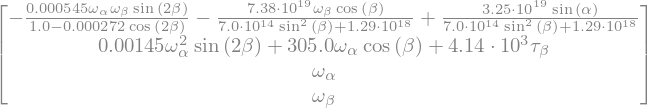

In [16]:
print('Standard Form Equations of Motion:')
N(f,3)

## 3. Linearizing the System

Now we want to approximate the nonlinear system dynamics near an equilibrium point by linearizing the system to have the form
$$
\dot{\mathbf{x}} = A\mathbf{x} + B\mathbf{u},
$$
where $\mathbf{x}$ is the ***linear state vector*** and $\mathbf{u}$ is the ***linear input vector***. We call this model ***state space form***. There are three steps we take to convert our current nonlinear, standard form system of equations into state space form:
1. Choose an ***equilibrium point*** towards which the controller will drive the system.
2. Define $\mathbf{x}$ and $\mathbf{u}$.
3. Calculate $A$, also called the ***state matrix***.
4. Calculate $B$, also called the ***input matrix***.

Let's begin by finding an equilibrium point. An equilibrium point is any combination of nonlinear state, $\mathbf{m_{e}}$, and nonlinear input, $\mathbf{n_{e}}$, such that
$$
f(\mathbf{m_{e}}, \mathbf{n_{e}}) = 0.
$$
This is also called a ***stationary point*** because the time derivative of the nonlinear state vector—also called the nonlinear velocity vector—is exactly zero. Remember, we already have $f$, so all we need to do is find a valid $\mathbf{m_{e}}$ and $\mathbf{n_{e}}$. This equilibrium point will be the state that our controller drives the system towards, i.e., if our controller works, as time goes to infinity, the system will go to this equilibrium point. This is called ***stablization***. Accordingly, it would make sense to choose the equilibrium point where the pendulum is balanced upright ($\alpha=0$) and no torque is being applied ($\tau_\beta=0$). Let's check to see how this limits the range of possible equilibrium points:

In [17]:
# Set the derivative states, gimbal states, and inputs to 0 to check what constraints equilibrium positions have on the yaw angle
sub_expr = {omega_alpha_sym : 0.0, # To be stationary, the derivative of alpha must be 0
            omega_beta_sym : 0.0,  # To be stationary, the derivative of beta must be 0
            tau_beta_sym : 0.0,    # We want the input to be 0 at the equilibrium position
            alpha_sym : 0.0,}      # We want the pendulum to be upright equilibrium position

# Evaluate the equations of motion
equil_f = f.evalf(subs=sub_expr)
print('Equilibrium Condition:')
N(equil_f, 3)

Equilibrium Condition:


Evaluating the equations of motion, we find that these constraints guarantee an equilibrium point. This means that, as long as $\alpha$ and $\tau_\beta$ are $0$, we can select any gimbal angle, $\beta$, we like and know we will have found an equilibrium point. For now, let's just select $\beta=0$.

In [18]:
# Our chosen equilibrium point
equilibrium_point = {omega_alpha_sym : 0.0,
                     omega_beta_sym : 0.0,
                     tau_beta_sym : 0.0,
                     alpha_sym : 0.0,
                     beta_sym : 0,} 

Because the output of our equations of motion at the selected nonlinear state vector and nonlinear input vector is 0, we have confirmed our choice is valid equilibrium point. Now we can move on to calculate the $A$ and $B$ matrices.

Recall, our system is currently in standard form:
$$
\dot{\mathbf{m}} = f(\mathbf{m},\mathbf{n}),
$$
and we have just found an equilibrium position such that 
$$
f(\mathbf{m_{e}}, \mathbf{n_{e}}) = 0.
$$

Suppose we Taylor expand our system around the equilibrium position:
$$
f(\mathbf{m}, \mathbf{n}) \approx f(\mathbf{m_{e}}, \mathbf{n_{e}}) + \left.\frac{\partial f}{\partial \mathbf{m}}\right|_{\mathbf{m_{e}}, \mathbf{n_{e}}}(\mathbf{m} - \mathbf{m_{e}}) + \left.\frac{\partial f}{\partial \mathbf{n}}\right|_{\mathbf{m_{e}}, \mathbf{n_{e}}}(\mathbf{n} - \mathbf{n_{e}}),
$$
where $\frac{\partial y}{\partial \mathbf{z}}$ represents the jacobian of $y$ with respect to the vector $\mathbf{z}$.

Because $f(\mathbf{m_{e}}, \mathbf{n_{e}})=0$ by design, and because $\dot{\mathbf{m}}=f(\mathbf{m},\mathbf{n})$, the above equation is equivalent to
$$
\dot{\mathbf{m}} \approx \left.\frac{\partial f}{\partial \mathbf{m}}\right|_{\mathbf{m_{e}}, \mathbf{n_{e}}}(\mathbf{m} - \mathbf{m_{e}}) + \left.\frac{\partial f}{\partial \mathbf{n}}\right|_{\mathbf{m_{e}}, \mathbf{n_{e}}}(\mathbf{n} - \mathbf{n_{e}}).
$$

Note that, because $\mathbf{m_{e}}$ is a constant,
$$
\dot{\mathbf{m}} = \frac{d}{dt} \left( \mathbf{m} - \mathbf{m_{e}} \right).
$$
Based on this fact, we can rewrite the left hand side of the Taylor expansion as
$$
\frac{d}{dt} \left( \mathbf{m} - \mathbf{m_{e}} \right) \approx \left.\frac{\partial f}{\partial \mathbf{m}}\right|_{\mathbf{m_{e}}, \mathbf{n_{e}}}(\mathbf{m} - \mathbf{m_{e}}) + \left.\frac{\partial f}{\partial \mathbf{n}}\right|_{\mathbf{m_{e}}, \mathbf{n_{e}}}(\mathbf{n} - \mathbf{n_{e}}).
$$

The above equation yields a natural definition for the linear state vector, $\mathbf{x}$, the linear input vector $\mathbf{u}$, the state matrix, $A$, and the input matrix $B$ such that
\begin{align}
\mathbf{x} &= \mathbf{m} - \mathbf{m_{e}}\\
\mathbf{u} &= \mathbf{n} - \mathbf{n_{e}}\\
A &= \left.\frac{\partial f}{\partial \mathbf{m}}\right|_{\mathbf{m_{e}}, \mathbf{n_{e}}}\\
B &= \left.\frac{\partial f}{\partial \mathbf{n}}\right|_{\mathbf{m_{e}}, \mathbf{n_{e}}}\\
\end{align}

Applying this change of variables, we arrive at the equation
$$
\dot{\mathbf{x}} \approx A\mathbf{x} + B\mathbf{u},
$$
which is state space form.

 Now that we have defined $A$ and $B$, we can calculate them from our standard form equations of motion and chosen equilibrium point. For $A$, this looks like:

A=


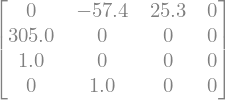

In [19]:
# Define the nonlinear state vector
m = [omega_alpha_sym, omega_beta_sym, alpha_sym, beta_sym]

# Take the jacobian of f with respect to the nonlinear state vector
A = f.jacobian(m)

# Evaluate A at our selected equilibrium point
A = A.evalf(subs=equilibrium_point)

# Print A
print('A=')
N(A,3)

Similarly for $B$:

B=


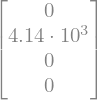

In [20]:
# Define the nonlinear input vector
n = [tau_beta_sym]

# Take the jacobian of f with respect to the nonlinear input vector
B = f.jacobian(n)

# Evaluate B at our selected equilibrium point
B = B.evalf(subs=equilibrium_point)

# Print B
print('B=')
N(B,3)

Summarizing the linearization process, once the system was placed in standard form we
1. Found the equilbrium point to which the controller will drive the system
2. Defined the linear state vector, $\mathbf{x}$, and linear input vector, $\mathbf{u}$.
3. Defined and calculated the state matrix, $A$.
4. Defined and calculated the input matrix, $B$.

This allows us to *approximate* the nonlinear system dynamics *near the chosen equilibrium point* by converting our nonlinear system,
$$
\begin{bmatrix}
\ddot{\alpha} \\
\ddot{\beta} \\
\end{bmatrix} = f(\dot{\alpha}, \dot{\beta}, \alpha, \beta, \tau_\beta),
$$
to a linear system in state space form:
$$
\dot{\mathbf{x}} \approx A\mathbf{x} + B\mathbf{u}.
$$

## 4. Controller Design

### 4a. Controllability

In the previous pendulum cart serieswe concluded that a closed-loop state space system will be ***asymptotically stable*** if and only if the real parts of the eigenvalues of the ***closed-loop response matrix***, $F=A-BK$, are all negative. Therefore, before attempting to solve for a set of control gains that satisfy this condition, we should determine if such a set of control gains even exist.

One approach to do this is by checking if the system is ***controllable***. A controllable system one in which, for all possible pairings of arbitrary initial states, $\mathbf{x_0}$, and terminal states, $\mathbf{x_f}$, there exists an unconstrained control sequence, $\mathbf{u}(t)$, that drives the system from $\mathbf{x_0}$ to $\mathbf{x_f}$ in a finite amount of time, $t_f$. If this condition is satisfied, then it is also true that we can find a gain matrix that places each eigenvalue of the closed-loop response matrix wherever we want.

As it turns out, for linear systems, we can prove controllability by demonstrating that there exists a control input which drives any initial condition, $\mathbf{x_0}$, to the origin, $\mathbf{x}_f=0$, in finite time. Let's see how we would do this now.

Consider our state space system $$\dot{\mathbf{x}} \approx A\mathbf{x} + B\mathbf{u}.$$

The solution to this system is given by
$$
    \mathbf{x}(t) = e^{At}\mathbf{x}_0 + \int_0^t e^{A(t-\tau)}B\mathbf{u}(\tau)d\tau
$$

Let's demonstrate that there exists a control input which drives any initial condition, $\mathbf{x_0}$, to the origin, $\mathbf{x}(t_f)=0$, i.e.,
$$
\forall \mathbf{x}_0 \quad \exists \mathbf{u}(t) \quad \text{such that},\quad0 = e^{At}\mathbf{x}_0 + \int_0^{t_f} e^{A({t_f}-\tau)}B\mathbf{u}(\tau)d\tau.
$$

Simplifying:
\begin{align}
e^{At_f}\mathbf{x}_0 &= -\int_0^{t_f} e^{A({t_f}-\tau)}B\mathbf{u}(\tau)d\tau \\
e^{At_f}\mathbf{x}_0 &= -e^{At_f} \int_0^{t_f} e^{-A\tau}B\mathbf{u}(\tau)d\tau \\
\mathbf{x}_0 &= -\int_0^{t_f} e^{-A\tau}B\mathbf{u}(\tau)d\tau. \\
\end{align}

Recall,

$$
e^{-A\tau} := I - A\tau + \frac{1}{2}(A\tau)^2 - \frac{1}{6}(A\tau)^3 + \ldots
$$

A special form of this infinite sum, derived via Sylvester's Matrix Formula, replaces this infinite sum with the finite sum:

$$
e^{-A\tau} = \sum_{k=0}^{n-1} \alpha_k(\tau)A^k,
$$

where $A$ is $n\times n$.

Substituting this into our previous equation, we have:

\begin{align}
\mathbf{x}_0 &= -\int_0^{t_f} \sum_{k=0}^{n-1}\left( \alpha_k(\tau)A^k\right)B\mathbf{u}(\tau)d\tau \\
\mathbf{x}_0 &= -\sum_{k=0}^{n-1} \left( A^kB \int_0^{t_f}  \alpha_k(\tau)\mathbf{u}(\tau)d\tau\right).
\end{align}


Let 
$$
\mathbf{w}_k(\mathbf{u}) := \int_0^{t_f}  \alpha_k(\tau)\mathbf{u}(\tau)d\tau,
$$

then

\begin{align}
\mathbf{x}_0 &= -\sum_{k=0}^{n-1}A^kB\mathbf{w}_k(\mathbf{u}) \\
\mathbf{x}_0 &= -\left(B\mathbf{w}_0(\mathbf{u}) + AB\mathbf{w}_1(\mathbf{u}) + A^2B\mathbf{w}_2(\mathbf{u}) + \ldots + A^{n-1}B\mathbf{w}_{n-1}(\mathbf{u})\right) \\
\mathbf{x}_0 &= \begin{bmatrix}B &|& AB &|& A^2B &|& \ldots &|& A^{n-1}B \end{bmatrix} \begin{bmatrix}\mathbf{w}_0(\mathbf{u}) \\ \mathbf{w}_1(\mathbf{u}) \\ \mathbf{w}_2(\mathbf{u}) \\ \vdots \\ \mathbf{w}_{n-1}(\mathbf{u})\end{bmatrix}.
\end{align}

Let 
$$
\mathcal{W} := \begin{bmatrix}B &|& AB &|& A^2B &|& \ldots &|& A^{n-1}B \end{bmatrix}
$$
and
$$
\mathcal{U}(\mathbf{u}) := \begin{bmatrix}\mathbf{w}_0(\mathbf{u}) \\ \mathbf{w}_1(\mathbf{u}) \\ \mathbf{w}_2(\mathbf{u}) \\ \vdots \\ \mathbf{w}_{n-1}(\mathbf{u})\end{bmatrix}
$$
then,
\begin{align}
\mathbf{x}_0 &= \mathcal{W}\mathcal{U}(\mathbf{u}).
\end{align}

Summarizing: a linear system
$$\dot{\mathbf{x}} \approx A\mathbf{x} + B\mathbf{u},$$
is controllable if and only if
$$
\forall \mathbf{x}_0 \quad \exists \mathcal{U}(\mathbf{u}) \quad \text{such that} \quad \mathbf{x}_0 = \mathcal{W}\mathcal{U}(\mathbf{u}),
$$
Clearly this is only true if and only if $\mathcal{W}$, which we will call the ***controllability matrix***, is full rank. We can check if $\mathcal{W}$ is full rank via its singular value decomposition: if $\mathcal{W}$ has exactly $n$ nonzero singular values, then it is full rank, and therefore, our linear system is controllable. When this is true, then we know that we can find a set of control gains that places each eigenvalue of the closed-loop response wherever we want.

Let's determine if our system is controllable now. To calculate $\mathcal{W}$ in code, we can use `numpy`'s `hstack` function:

Controllability Matix:


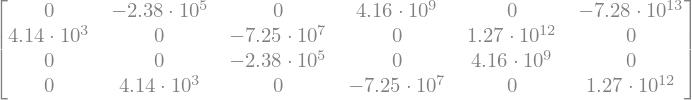

In [21]:
# Calculate the controllability matrix
ctrb = np.hstack((B, A@B, A@A@B, A@A@A@B, A@A@A@A@B, A@A@A@A@A@B)).astype(float)
print('Controllability Matix:')
N(Matrix(ctrb), 3)

Next, we will use `numpy.linalg`'s `svd` function to get the left and right singular vectors, $U$ and $V^h$, as well as the singular values, $s$.

In [22]:
# Get the single value decomposition of C
U, s, Vh = np.linalg.svd(ctrb, full_matrices=True)

Finally, to determine if the system is controllable, we will ensure that the number of nonzero singular values is exactly equal to the number of states:

In [23]:
# Determine controllability by comparing the number of nonzero single values to the number of states
n_nonzero_singular_vals = np.sum(~np.isclose(s, 0)) # Account for numerical errors with np.isclose
is_controllable = n_nonzero_singular_vals == len(m)
print(f"Is Controllable: {is_controllable}")

Is Controllable: True


Because the number of nonzero singular values of $\mathcal{W}$ is exactly equal to the number of states, $\mathcal{W}$ is full rank and our system is controllable. Therefore, we can find a gain matrix that places the eigenvalues of the closed-loop system to guarantee ***asymptotic stability***.

Beyond the binary of controllability, there is also more information stored in the controllability matrix. We can also determine how difficult specific directions in state space are to control, i.e., how much input energy is required to effect changes in certain state directions. This is done with further analysis of the singular value decomposition of $\mathcal{W}$. Specifically, the magnitude of the singular values determines the amount of energy required to control certain state directions (with larger singular values corresponding to less required energy) and the left singular vectors, i.e., the columns of $U$, determine what those state directions are. Let's investigate now:

First we will print the values of the singular values to determine how hard the directions defined by the columns of $U$ are to control:

Control Energy Required (Larger Value = Less Energy Needed):


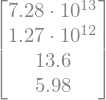

In [24]:
# Print the singular values of the controllability matrix
print('Control Energy Required (Larger Value = Less Energy Needed):')
N(Matrix(s),3)

We find that the first two state directions defined by the columns of $U$ will be easier to control (because thier singular values are larger) and the last two will be more difficult to control (because thier singular values are smaller). Next, we look at the columns of $U$:

First Controllability Mode:


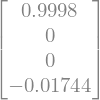

In [25]:
print('First Controllability Mode:')
N(Matrix(U[:,0]),4)

Second Controllability Mode:


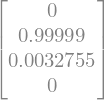

In [26]:
print('Second Controllability Mode:')
N(Matrix(U[:,1]),5)

Third Controllability Mode:


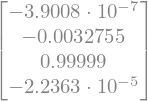

In [27]:
print('Third Controllability Mode:')
N(Matrix(U[:,2]),5)

Fourth Controllability Mode:


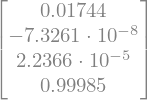

In [28]:
print('Fourth Controllability Mode:')
N(Matrix(U[:,3]),5)

The left singular vectors above tell us the ***controllability directions***. Each controllability direction indicates a particular direction in the state space that has an associated required control energy (as indicated by its associated singular value). For example, the first controllability direction, $\begin{bmatrix}0.9998\\ 0\\ 0\\ -0.01744\end{bmatrix}$, is the direction in state space associated with the first singular value, $7.28\cdot10^{13}$.

Because the controllability directions are linearly independent and span the entirety of the state space, they form a basis of the state space. This means that every direction in the state space can be represented by a linear combination of the controllability directions, and, similarly, the amount of energy required to control that direction can be represented by a combination of the associated singular values.

For example, in this particular system, the controllability directions are nearly perfectly aligned with the state space cardinal directions. As such, we can approximate the controllability directions as the state space cardinal directions. Recalling 
$$
\mathbf{m} = 
\begin{bmatrix}
{\omega}_{\alpha} \\
{\omega}_{\beta} \\
{\alpha} \\ 
{\beta}
\end{bmatrix},
$$
we find that the first controllability direction is approximately in the ${\omega}_{\alpha}$ direction, the second controllability direction is approximately in the ${\omega}_{\beta}$ direction, the third controllability direction is approximately in the $\alpha$ direction, and the fourth controllability direction is approximately in the $\beta$ direction. It will not always be the case that the controllability directions align with the cardinal state space directions. 

Looking at each of the controllability directions and thier associated singular values, we conclude that $\omega_\alpha$ and $\omega_\beta$ require very little input energy to control compared to $\alpha$ and $\beta$, and that $\beta$ requires the most overall energy to control.

### 4b. Implementing the Controller

Now that we know our system is controllable, we can design and implement a controller for it. In the Pendulum Cart series, we learned how to design and solve a ***Linear Quadratic Problem*** for our state space model to find an optimal controller, called a ***Linear Quadratic Regulator***. Repeating this process now, and again using ***Bryson's Rule*** to select an untuned ***state cost matrix, $Q$*** and untuned ***input cost matrix, $R$***, we find the following set of optimal control gains:

In [29]:
# Import the scipy package that solve the CARE
from scipy.linalg import solve_continuous_are

# Define the state and input cost matrices
Q = np.array([[1.62, 0., 0., 0.],
              [0., 1.62, 0., 0.],
              [0., 0., 131., 0.],
              [0., 0., 0., 0.405]])
R = np.array([[1.6e5]])

# Solve the CARE and calculate the gain matrix
P = solve_continuous_are(np.array(A, dtype=float), np.array(B, dtype=float), Q, R)
K = np.linalg.inv(R)@B.T@P
print("Optimal Gain Matrix:")
N(K,3)

Optimal Gain Matrix:


The next step is to test our controller in simulation. This project series's provided simulation function expects us to implement a controller function that takes as argument the nonlinear state of the system, $\mathbf{m}$, and return the torque applied to the gimbal. Implementing this in code:

In [30]:
def controller(state):
    """
    The controller function. Given some state information, it calculates a torque to apply to the gimbal joint that
    (hopefully) balances the pendulum upright.

    Parameters
    ----------
    state : dictionary of floats with the following keys
        omega_alpha : float
            The angular rate of the pendulum ring in radians / second.
        omega_beta : float
            The angular rate of the gimbal in radians / second.
        alpha : float
            The roll angle of the pendulum ring in radians with 0 being upright.
        beta : float
            The yaw angle of the gimbal in radians.

    Returns
    -------
    tau_beta : float
        The torque to apply to the gimbal joint
    """
    m_e = np.array([0, 0, 0, 0]) # The equilibrium nonlinear state vector
    n_e = np.array([0])          # The equilibrium nonlinear input vector

    # Build the nonlinear state vector
    m = np.array([state['omega_alpha'], state['omega_beta'], state['alpha'], state['beta']])

    # Build the linear state vector
    x = m - m_e

    # Apply the feedback control law with our selected gain matrix to get the linear input vector
    u = -K@x

    # Convert the linear input vector into the nonlinear input vector
    n = u + n_e

    # Return the nonlinear torque as a scalar
    tau_beta = n[0]
    return tau_beta

## 5. Running a Simulation

The backend for the simulation has already been made for you. The backend will handle building the simulation environment, running and visualizing the simulation, applying your controller's inputs, and tracking relevant data. Let's import this backend now. It is a function named `run` that is stored in a Python script named `sacmg.py`. 

In [31]:
# Import the project's backend.
from sacmg import run

Now we are ready to run the simulation and collect data. To do this, we simply call the `run` function as pass as arguments the initial angle of the pendulum and the controller function we just built. In this case, let's set the initial angle to 5 degrees. The simulation will automatically run, apply our controller, and return some data collected during simulation. The returned data is a dictionary with the values:

`data['time']` : list of n floats

    The time, in seconds, at which each data point is collected
    
`data['omega_alpha']` : list of n floats

    The angular rate of the pendulum ring, in radians per second, at each of the n data collection points.
    
`data['omega_beta']` : list of n floats

    The angular rate of the gimbal, in radians per second, at each of the n data collection points.
    
`data['alpha']` : list of n floats

    The roll angle of the pendulum ring, in radians, at each of the n data collection points.
    
`data['beta']`: list of n floats

    The yaw angle of the gimbal, in radians, at each of the n data collection points.
    
`data['tau_beta']` : list of n floats

    The torque applied to the gimbal, in Newton-meters, at each of the n data collection points.

In [32]:
# Run the simulation and collect the simulation data
data = run(0.08726, controller)

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7003/static/


Voila! Again our controller successfully drives the system to the selected equilibrium point and stays there. We can confirm the by plotting the results:

In [33]:
# Import plotting tool
import matplotlib.pyplot as plt
%matplotlib inline

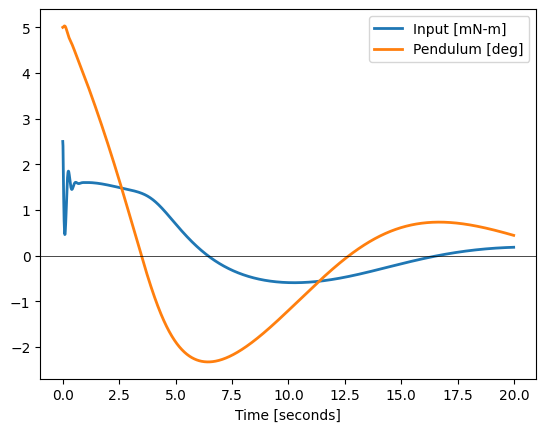

In [34]:
# Plot the error, derivative of the error, and torque as function of time
plt.plot(data['time'], 1000*data['tau_beta'], label='Input [mN-m]', lw=2.0) 
plt.plot(data['time'], data['alpha']*180/3.14, label='Pendulum [deg]', lw=2.0) 
plt.legend()
plt.xlabel('Time [seconds]')
plt.axhline(c='k', lw=0.5)
plt.show()

## Assignment

Now that we have a working controller, we will investigate how changes to the system parameters affect the controllability of the system as well as how modifying the cost matrices alter the behavior of the system. To do this we make changes to the parameters, recalculate the system dynamics, and investigate the new controllability matrix. Additionally, we will alter the cost matrices, recalculate the controller gains, rerun the simulation, and investigate the results.

1. We have seen that the gimbal direction is the least controllable direction in state space, that is, changing the gimbal angle requires the most control input energy. Investigate what impacts the system parameters ($\omega_F$, $m$, $l$, $I_AA$, $I_BB$, and $I_FB$) have on the controllability matrix.

    a. Select at least one system parameters and at least five new values for it. Comment how you would, as an engineer, modify the physical system to enforce these parameter changes.

    b. Recalculate the controllability matrix of the system for each of the five new values of your selected parameter and investigate the changes to the required control energy for each principal direction of the energy ellipsoid (the singular values) and the directions in state space of the principal directions of the energy ellipsoid (the left singular vectors). Make comments about how your changes to the system parameter affected the controllability of the system with specific emphasis on which directions in state space were made more difficult to control and which directions in state space were made easier to control. Use data to back up your comments.

   c. Based on your findings, suggest how you might modify the physical system to make it more controllable. 

2. When finding an equilibrium point for the system, if the angular rates, torque, and pendulum angle are set to 0, we saw that the gimbal angle, $\beta$, was free. This means that all possible values of $\beta$ give valid equilibrium points as long as the angular rates, torque, and pendulum angle are 0.

    a. Whereas we can select any value for $\beta$ when designing our controller, there might be a "best value". Calculate the controllability matrix over a range of equilibrium $\beta$ values. Make comments about how the equilibrium value of $\beta$ affects the controllability of the system with specific emphasis on which directions in state space were made more difficult to control and which directions in state space were made easier to control.

   b. In terms of controllability, what is the "best" equilibrium $\beta$ value? Why? 
   
3. Tune the gain matrix by modifying the cost matrices to maximize the largest valid initial pendulum angle. In this case, a valid initial angle is defined as an initial angle such that, at t = 20, the pendulum and gimbal are near their equilibrium points and that, at no point during the simulation, did the pendulum arm strike the chassis holding the system.

    a. What was the largest valid initial angle you achieved?

   
    b. Explain your tuning method and collect a set of simultion results to visualize the tuning process. For your simulations, you might find it helpful to run them as fast as possible without visualization (they will still collect simulation data, though). To do this, set the key word argument `"real_time"` of the run function to `False`. For example, to run the simulation as fast as possible without visualization, you would call: `data = run(initial_angle, controller, real_time=False)`.